# Overview

This notebook is designed for pre-processing data for ResNet model training.

This notebook is designed for macOS platform.

## 1. Preparations

First by first we declare the imports, settings and needed dataclasses.

In [13]:
import os

from random import Random

import cv2
import torch

import numpy as np
import pandas as pd
import albumentations as alb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

In [4]:
PROJECT_ROOT = "/Users/locked15/Repos.localized/Python/Study/UUST/Course 3/Semester 2/Practice/sludge-utilities/apps/ml/ml-training_lab/"
DATASET_FOLDER = "data/raw/"
IMAGES_FOLDER = "data/images/"
TARGET_DATASET_FILE = "metadata.parquet"

TARGET_COLUMNS = [
    "sandstone_sludge", "siltstone_sludge", "argillite_sludge",
    "radiolarite_sludge", "coal_sludge", "limestone_sludge",
    "clay_sludge", "other_sludge"
]

IMG_SIZE = 1024
BATCH_SIZE = 4

In [5]:
class SludgeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, target_cols: list, transform = None):
        self.df = df.reset_index(drop = True)
        self.img_dir = img_dir
        self.target_cols = target_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["sludge_image_path"])

        if not os.path.exists(img_path):
            print(f"! WARN: Image ({img_path}) does not exist. !")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        targets = row[self.target_cols].values.astype(np.float32)

        if self.transform:
            augmented = self.transform(image = image)
            image = augmented["image"]
        image = np.transpose(image, (2, 0, 1)).astype(np.float32) / 255.0

        return torch.tensor(image), torch.tensor(targets)

In [6]:
train_transform = alb.Compose([
    alb.RandomCrop(width = 720, height = 720, p = 1.0),
    alb.Resize(width = IMG_SIZE, height = IMG_SIZE),
    
    alb.HorizontalFlip(p = 0.5),
    alb.VerticalFlip(p = 0.5),
    alb.RandomRotate90(p = 0.5),
    alb.ShiftScaleRotate(shift_limit = 0.05, scale_limit = 0.1, rotate_limit = 30, p = 0.5, border_mode = cv2.BORDER_CONSTANT),
    
    alb.CLAHE(clip_limit = 2.0, tile_grid_size = (8, 8), p = 0.4), 
    alb.Sharpen(alpha = (0.1, 0.3), lightness = (0.5, 1.0), p = 0.3),
    alb.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 15, val_shift_limit = 10, p = 0.4),
])

val_transform = alb.Compose([
    alb.CenterCrop(width = 720, height = 720, p = 1.0),
    alb.Resize(width = IMG_SIZE, height = IMG_SIZE),
])

/Users/locked15/Repos.localized/Python/Study/UUST/Course 3/Semester 2/Practice/sludge-utilities/apps/ml/ml-training_lab/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 2. Dataset Loading

In [7]:
print("Loading dataset")

full_df = pd.read_parquet(os.path.join(PROJECT_ROOT, DATASET_FOLDER, TARGET_DATASET_FILE))
print(f"Original dataset size: {len(full_df)}.")

df_cleaned = full_df[full_df["is_augmented"] == False].reset_index(drop = True)
print(f"Augmentations-free dataset size: {len(df_cleaned)}.")

df_cleaned[TARGET_COLUMNS].head()

Loading dataset
Original dataset size: 2292.
Augmentations-free dataset size: 382.


,sandstone_sludge,siltstone_sludge,argillite_sludge,radiolarite_sludge,coal_sludge,limestone_sludge,clay_sludge,other_sludge
0,5,25,70,0,0,0,0,0
1,5,25,70,0,0,0,0,0
2,5,30,65,0,0,0,0,0
3,5,30,65,0,0,0,0,0
4,5,25,70,0,0,0,0,0


## 3. Test Dataset Creation

In [8]:
test_dataset = SludgeDataset(
    df = df_cleaned,
    img_dir = os.path.join(PROJECT_ROOT, IMAGES_FOLDER),
    target_cols = TARGET_COLUMNS,
    transform = train_transform
)
test_loader = DataLoader(test_dataset, 
                         batch_size = BATCH_SIZE, 
                         shuffle = True, 
                         num_workers = 0)

images_batch, targets_batch = next(iter(test_loader))
print(f"Images batch size (Batch, Channels, Height, Width): {images_batch.shape}.")
print(f"Targets batch size (Batch, Target_Features): {targets_batch.shape}.")

Images batch size (Batch, Channels, Height, Width): torch.Size([4, 3, 1024, 1024]).
Targets batch size (Batch, Target_Features): torch.Size([4, 8]).


## 4. Augmentation Results Showcase

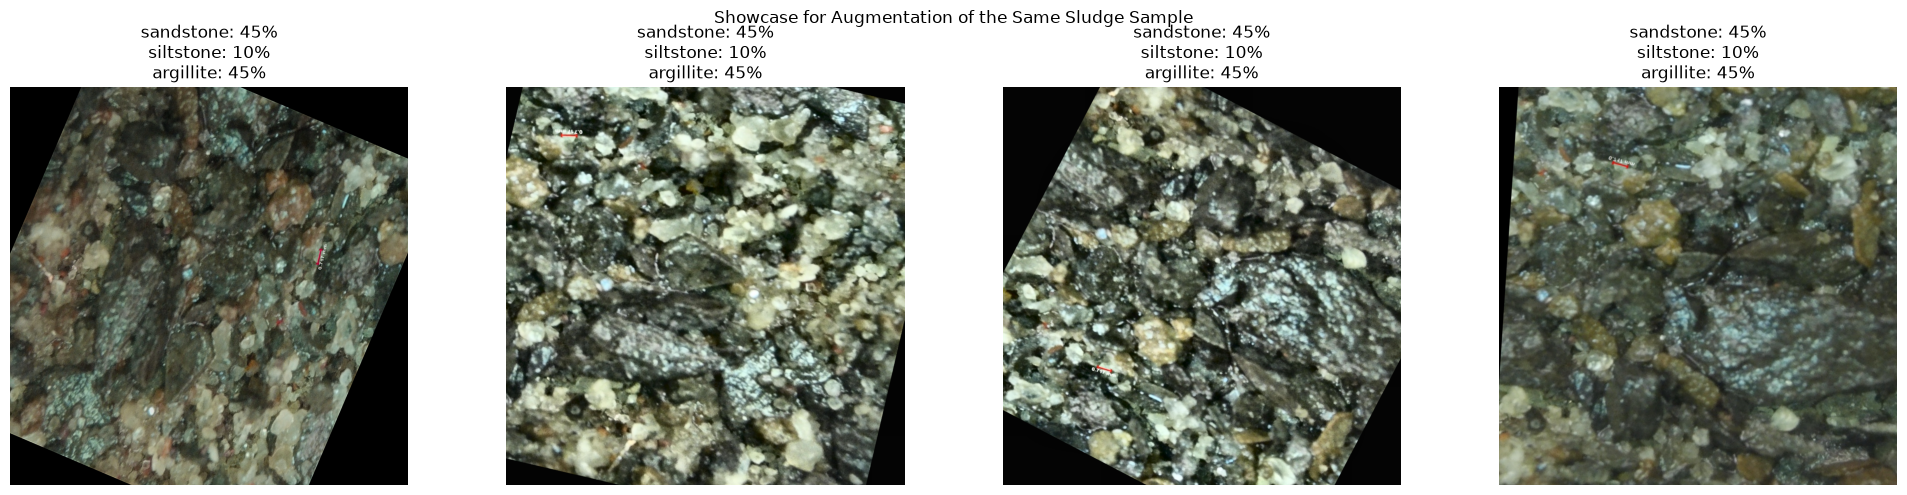

In [17]:
idx_to_view = Random().randint(0, len(df_cleaned))
fig, axes = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    img_tensor, target_vector = test_dataset[idx_to_view]
    img_to_show = img_tensor.numpy().transpose(1, 2, 0)

    labels = [f"{col.split("_")[0]}: {int(val)}%" for col, val in zip(TARGET_COLUMNS, target_vector) if val > 0]
    title_text = "\n".join(labels)

    axes[i].imshow(img_to_show)
    axes[i].set_title(title_text)
    axes[i].axis("off")

plt.suptitle("Showcase for Augmentation of the Same Sludge Sample")
plt.tight_layout()
plt.show()